In [1]:
!pip install visualkeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 24.4 MB/s eta 0:00:00


In [2]:
!pip install kaggle

In [3]:
from google.colab import files
files.upload()

!mv "kaggle (1).json" kaggle.json

import os
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d orvile/brain-cancer-mri-dataset

import zipfile
with zipfile.ZipFile('brain-cancer-mri-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')

Saving kaggle.json to kaggle.json
mv: cannot stat 'kaggle (1).json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/orvile/brain-cancer-mri-dataset
License(s): CC-BY-SA-4.0
100% 144M/144M [00:01<00:00, 126MB/s]



In [4]:
!unzip brain-cancer-mri-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Brain_Cancer raw MRI data/Brain_Cancer/brain_glioma/brain_glioma_1058.jpg  
  inflating: Brain_Cancer raw MRI data/Brain_Cancer/brain_glioma/brain_glioma_1059.jpg  
  inflating: Brain_Cancer raw MRI data/Brain_Cancer/brain_glioma/brain_glioma_1060.jpg  
  inflating: Brain_Cancer raw MRI data/Brain_Cancer/brain_glioma/brain_glioma_1061.jpg  
  inflating: Brain_Cancer raw MRI data/Brain_Cancer/brain_glioma/brain_glioma_1062.jpg  
  inflating: Brain_Cancer raw MRI data/Brain_Cancer/brain_glioma/brain_glioma_1063.jpg  
  inflating: Brain_Cancer raw MRI data/Brain_Cancer/brain_glioma/brain_glioma_1064.jpg  
  inflating: Brain_Cancer raw MRI data/Brain_Cancer/brain_glioma/brain_glioma_1065.jpg  
  inflating: Brain_Cancer raw MRI data/Brain_Cancer/brain_glioma/brain_glioma_1066.jpg  
  inflating: Brain_Cancer raw MRI data/Brain_Cancer/brain_glioma/brain_glioma_1067.jpg  
  inflating: Brain_Cancer raw MRI data/Brain_Cancer/brain_g

In [5]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import visualkeras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
from google.colab import files
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight

In [8]:
# ==============================
# 1. IMPORT LIBRARY
# ==============================
import os
import shutil
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ==============================
# 2. PATH DATASET ASLI
# ==============================
base_dir = 'Brain_Cancer raw MRI data/Brain_Cancer'
output_dir = 'dataset_split'

# ==============================
# 3. BUAT FOLDER SPLIT
# ==============================
for split in ['train', 'val', 'test']:
    for cls in os.listdir(base_dir):
        os.makedirs(os.path.join(output_dir, split, cls), exist_ok=True)

# ==============================
# 4. SPLIT DATA (70:15:15)
# ==============================
for cls in os.listdir(base_dir):
    class_path = os.path.join(base_dir, cls)
    images = os.listdir(class_path)

    train, temp = train_test_split(images, test_size=0.3, random_state=42)
    val, test = train_test_split(temp, test_size=0.5, random_state=42)

    # copy file
    for img in train:
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(output_dir, 'train', cls, img))

    for img in val:
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(output_dir, 'val', cls, img))

    for img in test:
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(output_dir, 'test', cls, img))

# ==============================
# 5. PATH BARU
# ==============================
train_dir = 'dataset_split/train'
val_dir   = 'dataset_split/val'
test_dir  = 'dataset_split/test'

# ==============================
# 6. IMAGE GENERATOR
# ==============================
train_datagen = ImageDataGenerator(
    rescale=1./255
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

# ==============================
# 7. LOAD DATA
# ==============================
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_gen = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# ==============================
# 8. CEK JUMLAH DATA
# ==============================
print("Train:", train_gen.samples)
print("Validation:", val_gen.samples)
print("Test:", test_gen.samples)

# ==============================
# 9. CEK LABEL
# ==============================
print(train_gen.class_indices)

Found 4237 images belonging to 3 classes.
Found 909 images belonging to 3 classes.
Found 910 images belonging to 3 classes.
Train: 4237
Validation: 909
Test: 910
{'brain_glioma': 0, 'brain_menin': 1, 'brain_tumor': 2}


In [9]:
import os

for cls in os.listdir(train_dir):
    jumlah = len(os.listdir(os.path.join(train_dir, cls)))
    print(cls, ":", jumlah)

brain_menin : 1402
brain_tumor : 1433
brain_glioma : 1402


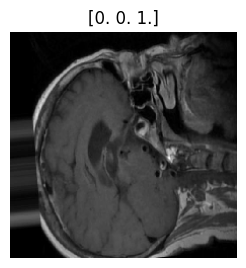

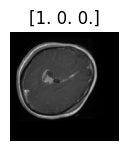

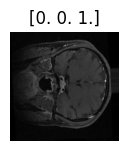

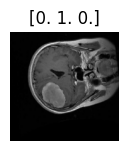

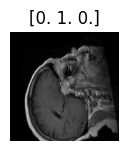

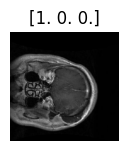

In [14]:
import matplotlib.pyplot as plt
import numpy as np

images, labels = next (train_gen)
plt.figure(figsize=(10, 10))
for i in range(6):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(labels[i])
    plt.axis("off")

    plt.show()

In [15]:
print(train_gen.class_indices)

{'brain_glioma': 0, 'brain_menin': 1, 'brain_tumor': 2}


In [16]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)

# 🔥 WAJIB: output layer
predictions = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [18]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

Epoch 1/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 55s 256ms/step - accuracy: 0.7460 - loss: 0.6016 - val_accuracy: 0.9032 - val_loss: 0.2982
Epoch 2/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 12s 92ms/step - accuracy: 0.8860 - loss: 0.3210 - val_accuracy: 0.9252 - val_loss: 0.2263
Epoch 3/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 12s 93ms/step - accuracy: 0.9065 - loss: 0.2631 - val_accuracy: 0.9307 - val_loss: 0.1982
Epoch 4/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 12s 89ms/step - accuracy: 0.9190 - loss: 0.2307 - val_accuracy: 0.9362 - val_loss: 0.1795
Epoch 5/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 12s 90ms/step - accuracy: 0.9162 - loss: 0.2128 - val_accuracy: 0.9351 - val_loss: 0.1880
Epoch 6/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step - accuracy: 0.9254 - loss: 0.1980 - val_accuracy: 0.9373 - val_loss: 0.1641
Epoch 7/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 12s 92ms/step - accuracy: 0.9311 - loss: 0.1909 - val_accuracy: 0.9450 - val_loss: 0.1540
Epoch 8/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 12s 91ms/step - accuracy: 0.9261 - loss: 0.1898 -

In [20]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20
)

Epoch 1/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 46s 212ms/step - accuracy: 0.8716 - loss: 0.3715 - val_accuracy: 0.9428 - val_loss: 0.1400
Epoch 2/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 13s 95ms/step - accuracy: 0.9287 - loss: 0.2128 - val_accuracy: 0.9494 - val_loss: 0.1380
Epoch 3/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 12s 92ms/step - accuracy: 0.9457 - loss: 0.1532 - val_accuracy: 0.9549 - val_loss: 0.1269
Epoch 4/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 13s 94ms/step - accuracy: 0.9559 - loss: 0.1180 - val_accuracy: 0.9582 - val_loss: 0.1170
Epoch 5/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 12s 90ms/step - accuracy: 0.9594 - loss: 0.1055 - val_accuracy: 0.9615 - val_loss: 0.1096
Epoch 6/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 12s 91ms/step - accuracy: 0.9707 - loss: 0.0820 - val_accuracy: 0.9637 - val_loss: 0.1043
Epoch 7/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 13s 96ms/step - accuracy: 0.9726 - loss: 0.0762 - val_accuracy: 0.9659 - val_loss: 0.0992
Epoch 8/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 12s 91ms/step - accuracy: 0.9816 - loss: 0.0569 -

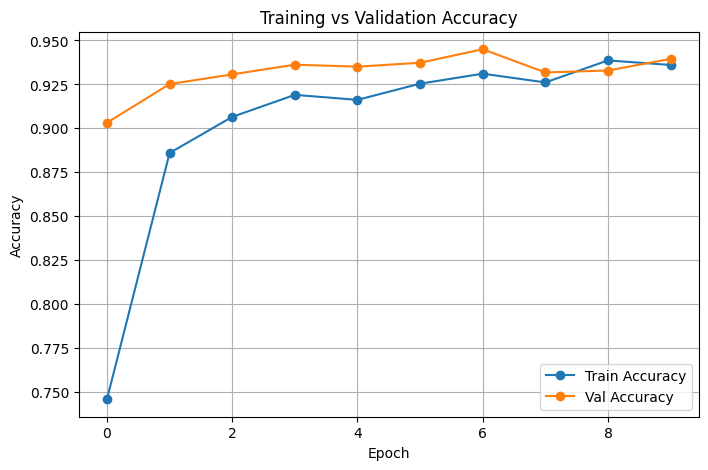

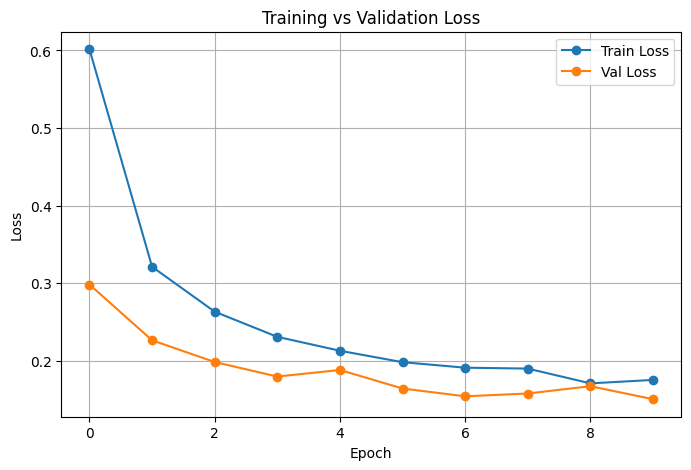

KeyError: 'auc'

<Figure size 800x500 with 0 Axes>

In [21]:
import matplotlib.pyplot as plt

# --- Akurasi ---
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# --- Loss ---
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='o')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# --- AUC ---
plt.figure(figsize=(8,5))
plt.plot(history.history['auc'], label='Train AUC', marker='o')
plt.plot(history.history['val_auc'], label='Val AUC', marker='o')
plt.title('Training vs Validation AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.grid(True)
plt.show()


In [24]:
test_loss, test_acc = model.evaluate(test_gen)

print(f"Test Accuracy: {test_acc:.4f}")

29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.9747 - loss: 0.0647
Test Accuracy: 0.9747


29/29 ━━━━━━━━━━━━━━━━━━━━ 11s 246ms/step
[[298   3   0]
 [  1 297   3]
 [  0   9 298]]


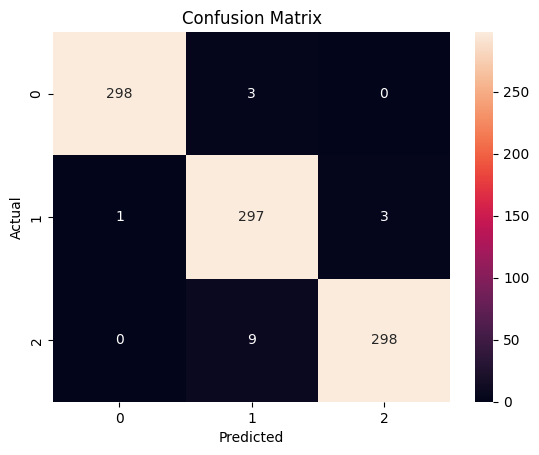

['brain_glioma', 'brain_menin', 'brain_tumor']


In [25]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
# reset generator (penting biar urutan benar)
val_gen.reset()

# prediksi
y_pred = model.predict(val_gen)

# ambil kelas dengan probabilitas tertinggi
y_pred_classes = np.argmax(y_pred, axis=1)

# label asli
y_true = val_gen.classes

cm = confusion_matrix(y_true, y_pred_classes)
print(cm)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

class_names = list(val_gen.class_indices.keys())
print(class_names)

In [28]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred = model.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_gen.classes

print(classification_report(y_true, y_pred_classes, target_names=test_gen.class_indices.keys()))

29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step 
              precision    recall  f1-score   support

brain_glioma       0.98      0.99      0.99       301
 brain_menin       0.96      0.97      0.96       301
 brain_tumor       0.98      0.96      0.97       308

    accuracy                           0.97       910
   macro avg       0.97      0.97      0.97       910
weighted avg       0.97      0.97      0.97       910

